# Global Explainability of Tabular Models
### Feature Importance, Partial Dependence Plots (PDP/ICE)
**Dataset:** UCI *Adult / Census Income* (`https://archive.ics.uci.edu/dataset/2/adult`)

---

## 1. Why "global" explainability?

Explainability methods split into two families:

| | Question answered | Typical output | Examples |
|---|---|---|---|
| **Local** | *Why did the model predict **this** for **this row**?* | one number per feature, per row | SHAP waterfall, LIME |
| **Global** | *What has the model learned **overall**?* | one number/curve per feature | permutation importance, PDP, mean\|SHAP\| |

This notebook builds one model and then interrogates it with four complementary **global** tools:


1. **Permutation importance** — model-agnostic, measures *how much performance depends on a feature*.
2. **Partial Dependence & ICE** — shows the *shape and direction* of a feature's effect, not just its size.


A key theme: *importance* (how much a feature matters) and *effect* (which way it pushes the prediction)
are different questions. Ranking plots answer the first; PDP and SHAP beeswarm answer the second.

## 2. Setup

Uncomment the install line the first time you run this notebook.

In [1]:
!pip install shap

In [2]:
import warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             classification_report, ConfusionMatrixDisplay)
import shap

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .3, "font.size": 10})
pd.set_option("display.width", 120)

# safe subsample: never asks for more rows than exist
def sample_df(df, n, seed=RANDOM_STATE):
    return df.sample(min(n, len(df)), random_state=seed)

print("pandas", pd.__version__, "| shap", shap.__version__)

pandas 2.2.2 | shap 0.52.0


## 3. Load the UCI Adult dataset

**Task:** predict whether a person's income exceeds \$50K/year from 14 census attributes
(48,842 rows, mixed numeric + categorical, missing values encoded as `?`).

The loader below tries three sources in order, so it works whichever packages/mirrors are available:

1. `ucimlrepo` (the official UCI python client),
2. the raw UCI CSV files,
3. OpenML via `sklearn.datasets.fetch_openml`.

In [3]:
RAW_COLS = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
            "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
            "hours-per-week", "native-country", "income"]

def _tidy(df):
    """Normalise column names, strip whitespace, turn '?' into NaN, binarise target."""
    df = df.copy()
    df.columns = [str(c).strip().lower().replace("-", "_").replace(".", "_")
                  for c in df.columns]
    # locate the target column whatever it is called
    tgt = next(c for c in ["income", "class", "target", "income_50k"] if c in df.columns)
    df = df.rename(columns={tgt: "income"})
    for c in df.select_dtypes(include=["object", "category", "string"]).columns:
        df[c] = df[c].astype(str).str.strip().replace({"?": np.nan, "nan": np.nan})
    # '>50K' and '>50K.' (the test split adds a period) both mean the positive class
    df["income"] = (df["income"].str.rstrip(".").str.strip() == ">50K").astype(int)
    return df

def load_adult():
    # --- 1) official UCI client -------------------------------------------
    try:
        from ucimlrepo import fetch_ucirepo
        ds = fetch_ucirepo(id=2)
        df = pd.concat([ds.data.features, ds.data.targets], axis=1)
        print("Source: ucimlrepo (UCI id=2)")
        return _tidy(df)
    except Exception as e:
        print("ucimlrepo unavailable ->", type(e).__name__)

    # --- 2) raw CSVs from the UCI machine-learning-databases mirror --------
    try:
        base = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/"
        tr = pd.read_csv(base + "adult.data", names=RAW_COLS, skipinitialspace=True)
        te = pd.read_csv(base + "adult.test", names=RAW_COLS, skipinitialspace=True,
                         skiprows=1)
        print("Source: raw UCI CSV files")
        return _tidy(pd.concat([tr, te], ignore_index=True))
    except Exception as e:
        print("raw UCI download failed ->", type(e).__name__)

    # --- 3) OpenML mirror --------------------------------------------------
    from sklearn.datasets import fetch_openml
    d = fetch_openml("adult", version=2, as_frame=True)
    print("Source: OpenML mirror")
    return _tidy(pd.concat([d.data, d.target.rename("income")], axis=1))

raw = load_adult()
print(raw.shape)
raw.head()

ucimlrepo unavailable -> ModuleNotFoundError
Source: raw UCI CSV files
(48842, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


### 3.1 Light cleaning

Two columns are dropped for principled reasons — this matters for explainability, not just accuracy:

* **`fnlwgt`** is a census *sampling weight*. It is not a property of the person, so any importance
  the model assigns to it is noise we would have to explain away later.
* **`education`** is a perfect string duplicate of the ordinal **`education_num`**. Leaving both in
  would **split the credit** between two copies of the same information and make *every*
  importance measure understate education. Redundant/correlated features are the single most common
  cause of confusing explainability results.

In [4]:
df = raw.drop(columns=[c for c in ["fnlwgt", "education"] if c in raw.columns])

TARGET = "income"
y = df[TARGET]
X = df.drop(columns=[TARGET])

NUM_FEATURES = X.select_dtypes(include=np.number).columns.tolist()
CAT_FEATURES = [c for c in X.columns if c not in NUM_FEATURES]

# PDP needs floats: integer grids get silently rounded (and error out in sklearn >= 1.9)
X[NUM_FEATURES] = X[NUM_FEATURES].astype(float)

# Missingness becomes its own level. Two reasons, both about explainability:
#   (a) mixing NaN with strings in a categorical column breaks PDP's grid construction;
#   (b) in Adult, a missing workclass/occupation is itself predictive, so imputing it
#       away would silently delete a signal the explanations should surface.
X[CAT_FEATURES] = X[CAT_FEATURES].fillna("Missing")

print(f"rows={len(X):,}   positives={y.mean():.1%}")
print("numeric    :", NUM_FEATURES)
print("categorical:", CAT_FEATURES)
print("\nmissing values per column (after encoding NaN as a 'Missing' level):")
print(X.isna().sum().loc[lambda s: s > 0].to_string() or "  none")
X.head()

rows=48,842   positives=23.9%
numeric    : ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
categorical: ['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']

missing values per column (after encoding NaN as a 'Missing' level):
Series([], )


,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
0,39.0,State-gov,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States
1,50.0,Self-emp-not-inc,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States
2,38.0,Private,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States
3,53.0,Private,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States
4,28.0,Private,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba


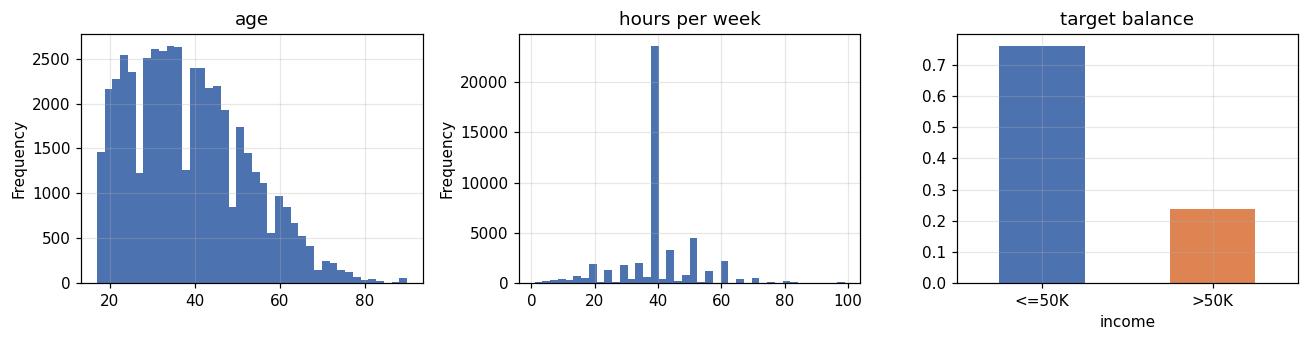

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
X["age"].plot.hist(bins=40, ax=axes[0], title="age", color="#4C72B0")
X["hours_per_week"].plot.hist(bins=40, ax=axes[1], title="hours per week", color="#4C72B0")
y.value_counts(normalize=True).rename({0: "<=50K", 1: ">50K"}).plot.bar(
    ax=axes[2], title="target balance", color=["#4C72B0", "#DD8452"], rot=0)
plt.tight_layout(); plt.show()

## 4. Preprocessing + model

Everything lives inside a single `Pipeline`. This is not cosmetic — it is what makes the rest of the
notebook correct:

* `permutation_importance` and `PartialDependenceDisplay` are handed the **pipeline**, so they
  perturb the *original, human-readable* columns (`occupation`, not `occupation_Sales`) and the
  encoding is re-applied on the fly.
* SHAP's `TreeExplainer` instead needs the **fitted tree model** and the **encoded matrix**, so we
  extract those separately in §8 and map the results back afterwards.

`min_samples_leaf=20` keeps the forest small enough that exact TreeSHAP runs in seconds rather than
minutes, at essentially no cost in accuracy.

In [6]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), NUM_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False,
                              min_frequency=30), CAT_FEATURES),
    ],
    verbose_feature_names_out=True,
)

model = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=20, max_features="sqrt",
    n_jobs=-1, random_state=RANDOM_STATE,
)

pipe = Pipeline([("prep", preprocess), ("model", model)])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

pipe.fit(X_train, y_train)

proba = pipe.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)
print(f"accuracy : {accuracy_score(y_test, pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, proba):.4f}\n")
print(classification_report(y_test, pred, target_names=["<=50K", ">50K"]))

accuracy : 0.8632
ROC AUC  : 0.9140

              precision    recall  f1-score   support

       <=50K       0.88      0.95      0.91      9289
        >50K       0.80      0.57      0.67      2922

    accuracy                           0.86     12211
   macro avg       0.84      0.76      0.79     12211
weighted avg       0.86      0.86      0.85     12211



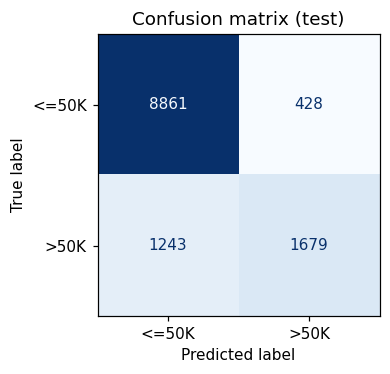

In [7]:
fig, ax = plt.subplots(figsize=(4, 3.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred, display_labels=["<=50K", ">50K"], cmap="Blues",
    colorbar=False, ax=ax)
ax.grid(False); ax.set_title("Confusion matrix (test)")
plt.tight_layout(); plt.show()

## 6. Method 1 — Permutation importance

**Idea:** shuffle one column, breaking its relationship with the target while preserving its
marginal distribution, and measure how much a *scoring metric* degrades.

$$\text{PFI}_j \;=\; s(f, X, y) \;-\; \frac{1}{K}\sum_{k=1}^{K} s\!\left(f, X^{(k)}_{\pi_j}, y\right)$$

**Advantages:** model-agnostic; expressed in units of the metric you actually care about; computed
on **held-out** data, so it measures *generalising* signal.

**Caveats:**
* With **correlated features**, permuting one creates impossible rows (`age=20`, `marital_status=Widowed`)
  and the model is evaluated off-distribution.
* Correlated features **share credit**: two duplicate columns can each score ~0 because the model
  falls back on the other. Low permutation importance means *"the model does not need this column"*,
  **not** *"this variable is irrelevant"*.

We score with **ROC AUC** rather than accuracy — on a 24%-positive target, accuracy is too blunt to
register the degradation.

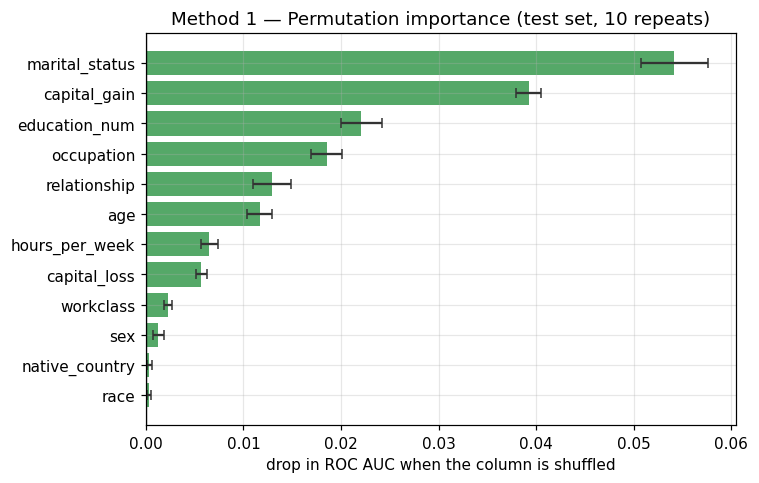

,mean,std
marital_status,0.0542,0.0034
capital_gain,0.0392,0.0012
education_num,0.0221,0.0021
occupation,0.0185,0.0016
relationship,0.0129,0.0019
age,0.0117,0.0013
hours_per_week,0.0065,0.0008
capital_loss,0.0057,0.0006
workclass,0.0023,0.0004
sex,0.0013,0.0005


In [8]:
# a 6,000-row subsample keeps runtime ~1 min without changing the ranking materially
sub = rng.choice(len(X_test), size=min(6000, len(X_test)), replace=False)
X_pi, y_pi = X_test.iloc[sub], y_test.iloc[sub]

pfi = permutation_importance(
    pipe, X_pi, y_pi, scoring="roc_auc",
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)

pfi_df = (pd.DataFrame({"mean": pfi.importances_mean, "std": pfi.importances_std},
                       index=X_pi.columns)
            .sort_values("mean", ascending=False))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(pfi_df.index[::-1], pfi_df["mean"][::-1],
        xerr=pfi_df["std"][::-1], color="#55A868", ecolor="#333", capsize=3)
ax.axvline(0, color="k", lw=.8)
ax.set_xlabel("drop in ROC AUC when the column is shuffled")
ax.set_title("Method 1 — Permutation importance (test set, 10 repeats)")
plt.tight_layout(); plt.show()

pfi_df.round(4)

**Reading the plot:** features whose error bar crosses zero are indistinguishable from noise for this
model. A *negative* mean is not a paradox — it means shuffling the column slightly *helped*, which is
what you expect from a variable the model uses only to fit noise.

### 6.1 Train vs test permutation importance — a free overfitting diagnostic

Running the same procedure on the training set and comparing is one of the most useful diagnostics in
this notebook: features that are important **only** on train are features the model has memorised.

## sub_tr = rng.choice(len(X_train), size=min(6000, len(X_train)), replace=False)
pfi_train = permutation_importance(
    pipe, X_train.iloc[sub_tr], y_train.iloc[sub_tr], scoring="roc_auc",
    n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)

cmp = pd.DataFrame({"train": pfi_train.importances_mean,
                    "test": pfi.importances_mean},
                   index=X_train.columns).sort_values("test", ascending=False)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
cmp.iloc[::-1].plot.barh(ax=ax, color=["#C44E52", "#55A868"], width=.8)
ax.set_xlabel("drop in ROC AUC"); ax.axvline(0, color="k", lw=.8)
ax.set_title("Permutation importance: train vs test")
plt.tight_layout(); plt.show()

cmp.assign(gap=lambda d: d["train"] - d["test"]).round(4)

## 2. Method  — Partial Dependence & ICE

Importance rankings tell you *how much* a feature matters. They say nothing about **direction** or
**shape**: is the effect linear? monotone? does it saturate?

The partial dependence of the model $f$ on feature $S$ marginalises over all the other features $C$
using their **empirical** distribution:

$$\hat f_S(x_S) \;=\; \frac{1}{n}\sum_{i=1}^{n} f\!\left(x_S,\; x^{(i)}_C\right)$$

In words: force the whole dataset to take one value of `age`, average the predictions, repeat across
a grid. The result is the model's average response curve.

**The two caveats that matter:**

1. **Extrapolation.** The formula evaluates every combination $(x_S, x^{(i)}_C)$, including ones that
   never occur — 80-year-olds with 60-hour weeks and 16 years of education. Where a feature is
   correlated with others, part of the PDP is drawn from regions with no data.
2. **Averaging hides heterogeneity.** A flat PDP can mean "no effect" *or* "strongly positive for half
   the population, strongly negative for the other half". **ICE** curves (one line per individual,
   next section) are what distinguish these two cases.

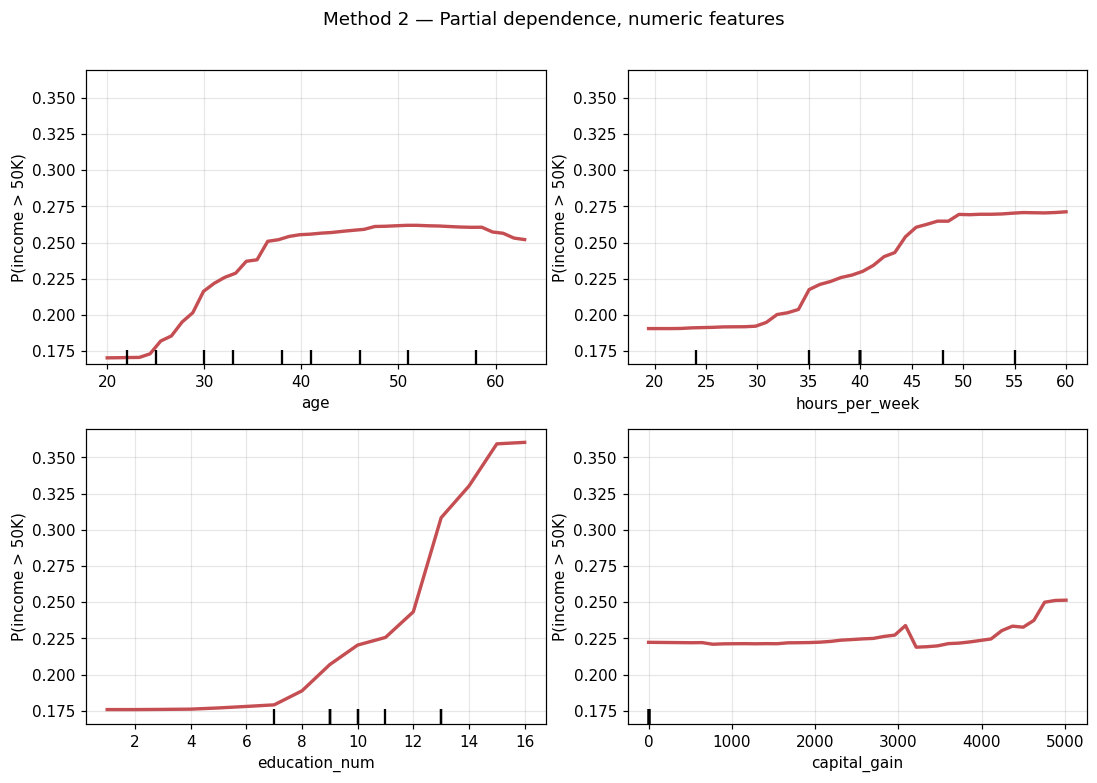

In [9]:
pdp_num = ["age", "hours_per_week", "education_num", "capital_gain"]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
PartialDependenceDisplay.from_estimator(
    pipe, sample_df(X_test, 4000),
    features=pdp_num, kind="average", grid_resolution=40,
    ax=axes.ravel(), line_kw={"color": "#C44E52", "lw": 2.2},
    random_state=RANDOM_STATE)
for a in axes.ravel():
    a.set_ylabel("P(income > 50K)")
fig.suptitle("Method 2 — Partial dependence, numeric features", y=1.01)
plt.tight_layout(); plt.show()

The **rug marks** along the x-axis show the deciles of the data. Where they are sparse (the far right
of `capital_gain`), the curve is an extrapolation and should not be quoted as a finding.

Typical shapes on this dataset: `age` rises then plateaus and falls after retirement age;
`education_num` is close to monotone with a step at the college threshold; `capital_gain` saturates
almost immediately — the model has essentially learned "any capital gain at all" as a binary flag.

### 7.1 Categorical PDP

scikit-learn draws a bar chart when a feature is declared categorical, using the model's response to
each *level* rather than an interpolated grid. Because we pass the **pipeline**, we can name the
original column — the one-hot encoding is re-applied internally.

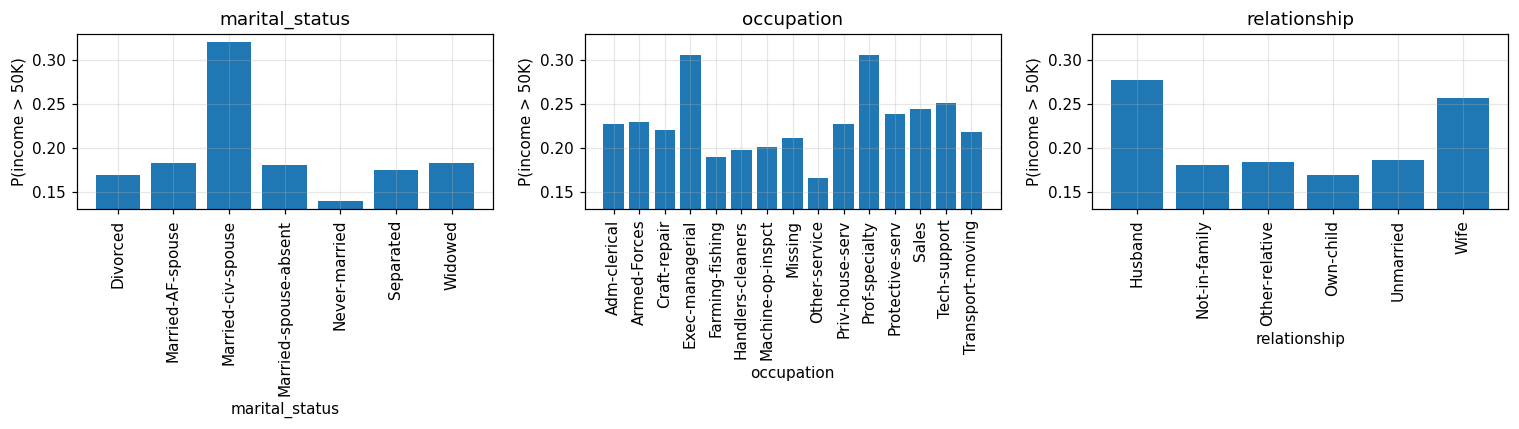

In [10]:
pdp_cat = ["marital_status", "occupation", "relationship"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
PartialDependenceDisplay.from_estimator(
    pipe, sample_df(X_test, 3000),
    features=pdp_cat, categorical_features=pdp_cat,
    ax=axes, random_state=RANDOM_STATE)
for a, name in zip(axes, pdp_cat):
    a.set_title(name); a.tick_params(axis="x", rotation=90)
    a.set_ylabel("P(income > 50K)")
plt.tight_layout(); plt.show()

### 7.2 ICE — un-averaging the PDP

Each thin line is one individual's prediction as we sweep the feature; the thick line is their
average, i.e. the PDP. **Centred ICE** (`centered=True`) subtracts each curve's value at the left
edge, so all lines start at 0 and only the *change* is compared — this is what reveals whether the
population moves together.

*Fanning* lines = the feature's effect depends on other features = **interactions**.

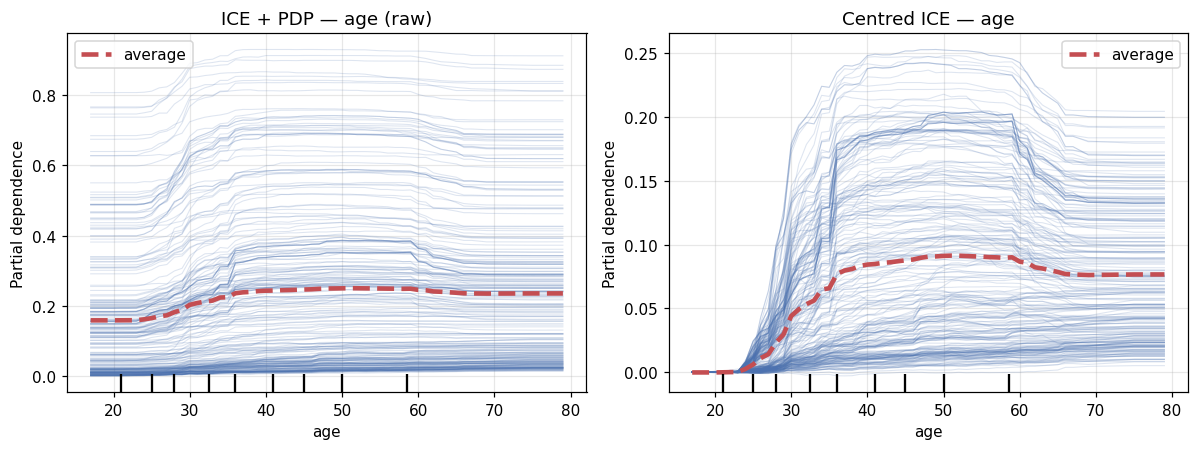

In [11]:
ice_sample = sample_df(X_test, 250)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
PartialDependenceDisplay.from_estimator(
    pipe, ice_sample, features=["age"], kind="both", ax=axes[0],
    ice_lines_kw={"color": "#4C72B0", "alpha": .18, "lw": .7},
    pd_line_kw={"color": "#C44E52", "lw": 3}, random_state=RANDOM_STATE)
axes[0].set_title("ICE + PDP — age (raw)")

PartialDependenceDisplay.from_estimator(
    pipe, ice_sample, features=["age"], kind="both", centered=True, ax=axes[1],
    ice_lines_kw={"color": "#4C72B0", "alpha": .18, "lw": .7},
    pd_line_kw={"color": "#C44E52", "lw": 3}, random_state=RANDOM_STATE)
axes[1].set_title("Centred ICE — age")
for a in axes:
    a.set_ylabel("P(income > 50K)")
plt.tight_layout(); plt.show()

### 7.3 Two-way PDP — visualising an interaction

A 2-D partial dependence surface marginalises over everything *except* two features. If the contours
were parallel horizontal/vertical bands the features would act additively; contours that bend show
the effect of one depends on the level of the other.

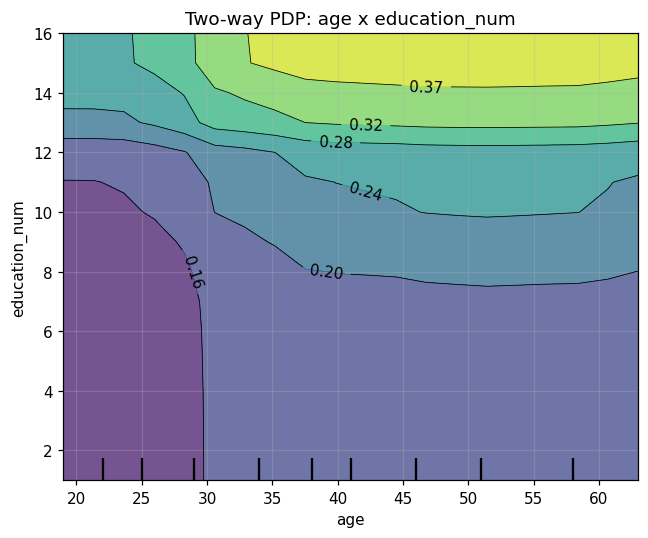

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
PartialDependenceDisplay.from_estimator(
    pipe, sample_df(X_test, 2000),
    features=[("age", "education_num")], kind="average",
    grid_resolution=20, ax=ax, random_state=RANDOM_STATE)
ax.set_title("Two-way PDP: age x education_num")
plt.tight_layout(); plt.show()

## 10. Summary and practical guidance

| Method | Scope | Model-agnostic? | Gives direction? | Main weakness |
|---|---|---|---|---|
| **Permutation** | global | yes | no | breaks feature correlation; shared credit |
| **PDP / ICE** | global | yes | **yes** | extrapolates off-manifold; averages hide subgroups |



### References

* Friedman, J. (2001). *Greedy Function Approximation: A Gradient Boosting Machine.* — original PDP.
* Goldstein et al. (2015). *Peeking Inside the Black Box* — ICE plots.
* Breiman, L. (2001). *Random Forests* — permutation importance.
* Lundberg & Lee (2017). *A Unified Approach to Interpreting Model Predictions* — SHAP.
* Lundberg et al. (2020). *From local explanations to global understanding with explainable AI for trees* — TreeSHAP.
* Molnar, C. *Interpretable Machine Learning* — https://christophm.github.io/interpretable-ml-book/
* scikit-learn User Guide §4.1 (Partial dependence) and §4.2 (Permutation importance).

# Explainable AI Using PDP, ICE, and PFI

### Dataset

Use the **UCI Wine Quality Dataset** to build a machine learning model for predicting wine quality from its physicochemical properties.

### Objective

In this experiment, apply three Explainable AI (XAI) techniques:

* **Partial Dependence Plot (PDP)** – to understand the average effect of a feature on model predictions.
* **Individual Conditional Expectation (ICE)** – to understand how a feature affects predictions for individual samples.
* **Permutation Feature Importance (PFI)** – to identify the features that have the greatest impact on model performance.

### Task 1: Load and Prepare the Dataset

* Load the Wine Quality dataset.
* Display the first few records.
* Check the dataset dimensions, data types, and missing values.
* Separate the input features (`X`) and target variable (`y`).
* Split the data into training and testing sets.

### Task 2: Train a Machine Learning Model

* Select an appropriate machine learning algorithm.
* Train the model using the training dataset.
* Evaluate the model using suitable performance metrics.
* Report the model performance on the test dataset.

### Task 3: Partial Dependence Plot (PDP)

Generate PDPs for:

* `alcohol`
* `volatile acidity`
* `sulphates`

**Comment:**
Explain how the predicted wine quality changes when each feature varies, while the effects of the other features are averaged out.

### Task 4: Individual Conditional Expectation (ICE)

Generate ICE plots for:

* `alcohol`
* `volatile acidity`
* `sulphates`

Use at least **10 individual wine samples**.

**Comment:**
Explain how the prediction changes for each individual sample as the selected feature changes. Compare the individual curves with the overall PDP trend.

### Task 5: Permutation Feature Importance (PFI)

Calculate PFI for **all input features**.

* Randomly shuffle one feature at a time.
* Measure the decrease in model performance.
* Rank the features according to their PFI scores.
* Display the results using a bar chart.

**Comment:**
Identify which features are most important to the model based on the decrease in performance after permutation.

### Task 6: Compare PDP, ICE, and PFI

Compare the results obtained from all three XAI techniques.

Discuss:

1. Which features are most influential?
2. What is the relationship between the important features and the prediction?
3. Is the relationship linear or nonlinear?
4. Do individual ICE curves follow the average PDP trend?
5. Are there differences between individual samples?
6. Does the PFI ranking agree with the PDP and ICE observations?

### Final Observation

Write a short conclusion explaining how **PDP, ICE, and PFI provide complementary information** about the behavior and importance of features in the trained machine learning model.




---



TASK-01-Solution



---



In [13]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

In [14]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

df = pd.read_csv(url, sep=";")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1599, 12)


In [15]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [16]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1599
Number of columns: 12


In [17]:
df.dtypes

,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


In [18]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [19]:
X = df.drop("quality", axis=1)
y = df["quality"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1599, 11)
y shape: (1599,)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training data:
X_train: (1279, 11)
y_train: (1279,)

Testing data:
X_test: (320, 11)
y_test: (320,)




---



TASK-02-Solution



---



In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [22]:
model = RandomForestRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print(model)

RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)


In [24]:
model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [25]:
y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[5.35666667 5.18666667 5.45333333 5.17       5.98666667 5.04333333
 5.1        4.91666667 6.07666667 5.89      ]


In [26]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance on Test Set")
print("--------------------------------")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Model Performance on Test Set
--------------------------------
MAE  : 0.4238
RMSE : 0.5536
R²   : 0.5311


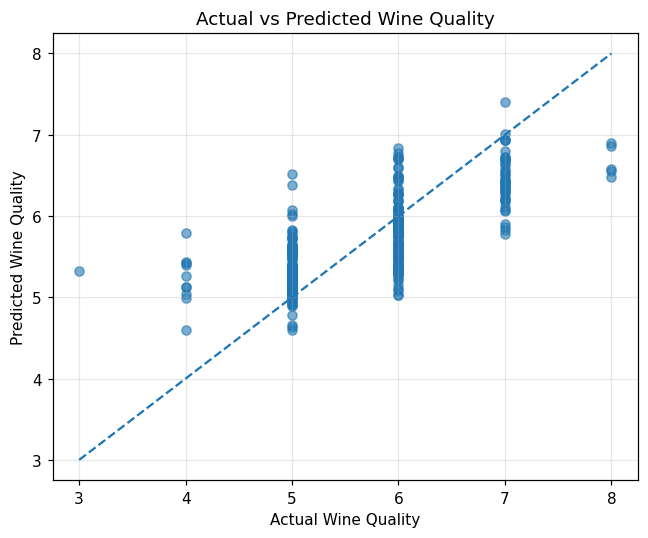

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Wine Quality")
plt.ylabel("Predicted Wine Quality")
plt.title("Actual vs Predicted Wine Quality")

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.tight_layout()
plt.show()

In [28]:
feature_names = X.columns.tolist()

print("Features:")
for i, feature in enumerate(feature_names, start=1):
    print(f"{i}. {feature}")

Features:
1. fixed acidity
2. volatile acidity
3. citric acid
4. residual sugar
5. chlorides
6. free sulfur dioxide
7. total sulfur dioxide
8. density
9. pH
10. sulphates
11. alcohol




---



TASK-03-Solution



---



In [29]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

In [30]:
pdp_features = [
    "alcohol",
    "volatile acidity",
    "sulphates"
]

print("Features selected for PDP:")
print(pdp_features)

Features selected for PDP:
['alcohol', 'volatile acidity', 'sulphates']


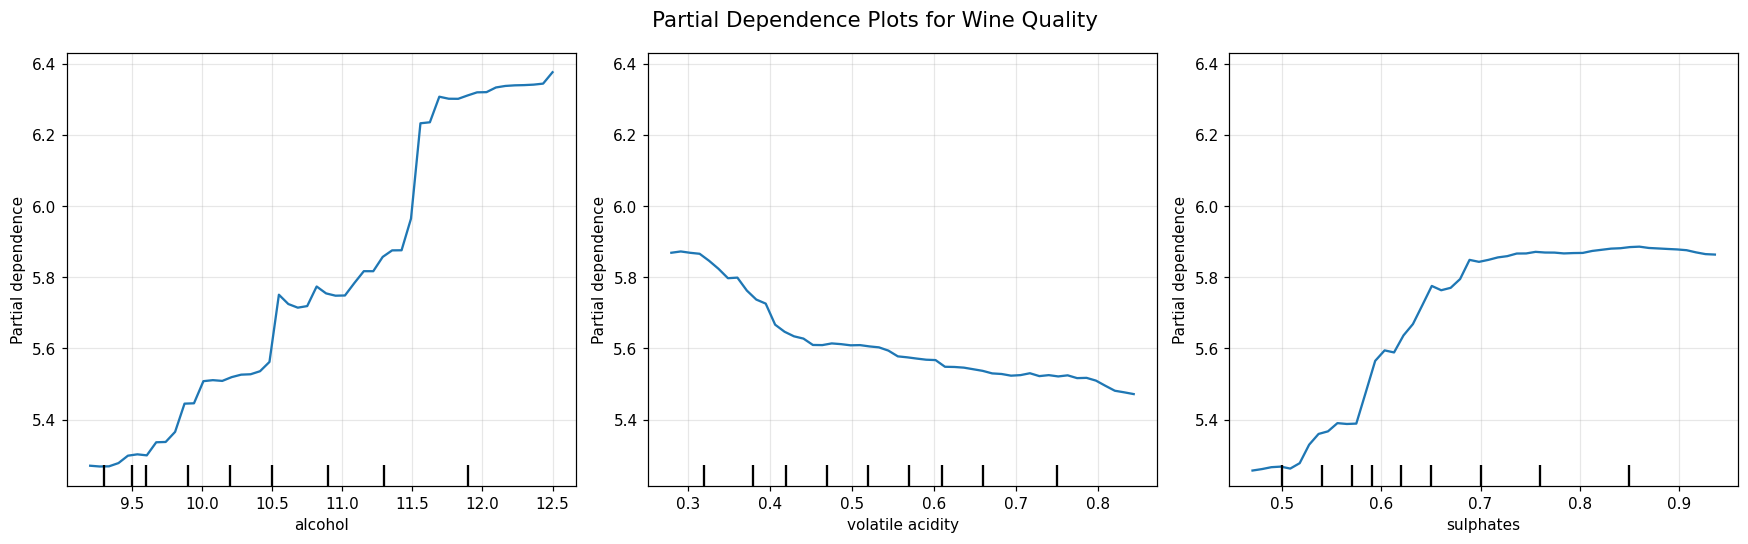

In [31]:
fig, ax = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(16, 5)
)

PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    features=pdp_features,
    kind="average",
    grid_resolution=50,
    ax=ax
)

fig.suptitle(
    "Partial Dependence Plots for Wine Quality",
    fontsize=14
)

plt.tight_layout()
plt.show()

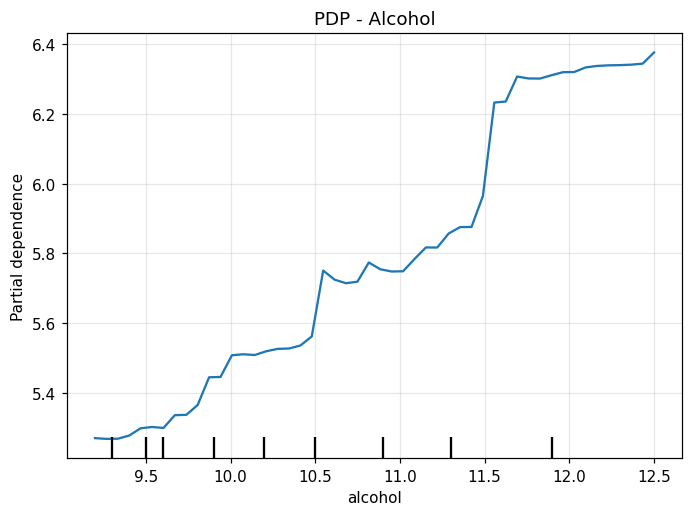

In [32]:
PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    features=["alcohol"],
    kind="average",
    grid_resolution=50
)

plt.title("PDP - Alcohol")
plt.tight_layout()
plt.show()

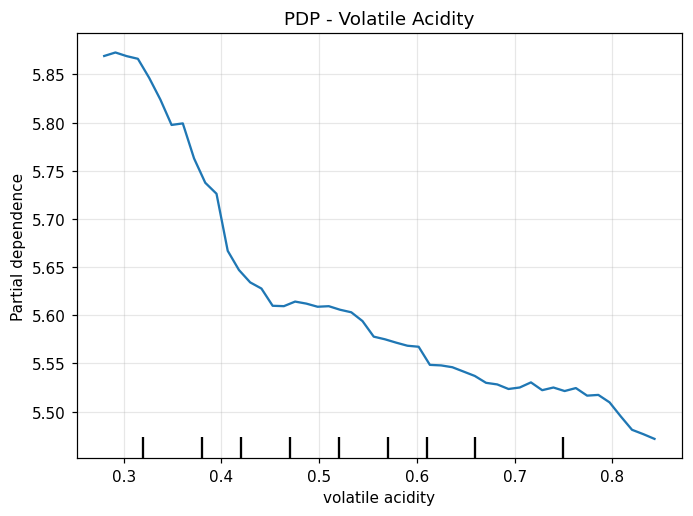

In [33]:
PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    features=["volatile acidity"],
    kind="average",
    grid_resolution=50
)

plt.title("PDP - Volatile Acidity")
plt.tight_layout()
plt.show()

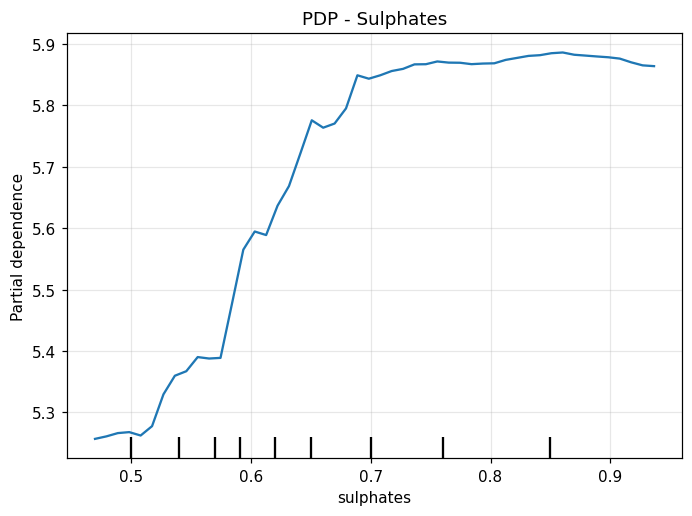

In [34]:
PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    features=["sulphates"],
    kind="average",
    grid_resolution=50
)

plt.title("PDP - Sulphates")
plt.tight_layout()
plt.show()



---



TASK-04-Solution



---



In [35]:
# Select 10 individual wine samples for ICE analysis
X_ice = X_test.iloc[:10].copy()

print("Number of samples used for ICE:", len(X_ice))
print("Shape:", X_ice.shape)

Number of samples used for ICE: 10
Shape: (10, 11)


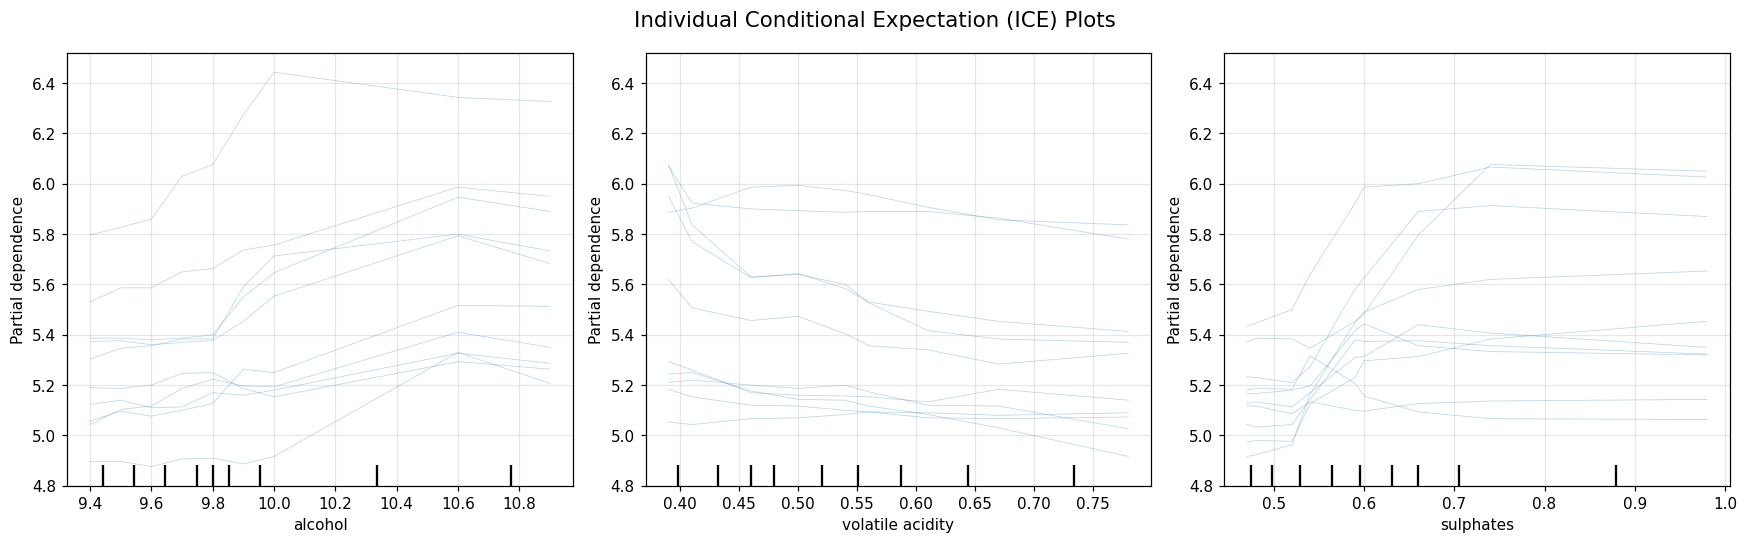

In [36]:
features_ice = [
    "alcohol",
    "volatile acidity",
    "sulphates"
]

fig, ax = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(16, 5)
)

PartialDependenceDisplay.from_estimator(
    model,
    X_ice,
    features=features_ice,
    kind="individual",
    grid_resolution=50,
    ax=ax
)

fig.suptitle(
    "Individual Conditional Expectation (ICE) Plots",
    fontsize=14
)

plt.tight_layout()
plt.show()

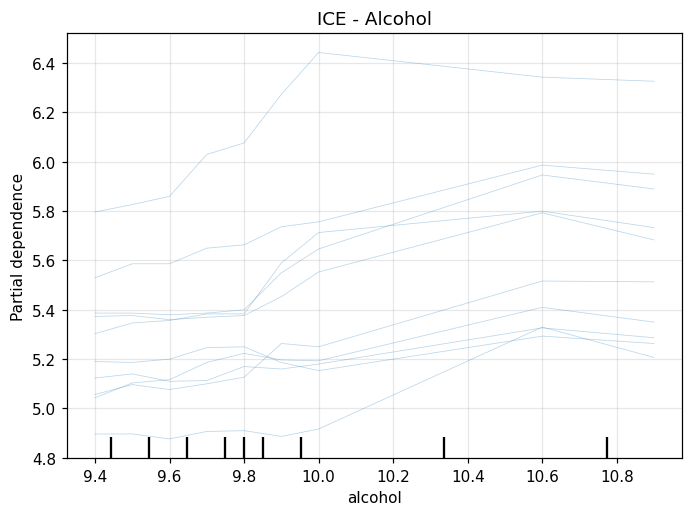

In [37]:
PartialDependenceDisplay.from_estimator(
    model,
    X_ice,
    features=["alcohol"],
    kind="individual",
    grid_resolution=50
)

plt.title("ICE - Alcohol")
plt.tight_layout()
plt.show()

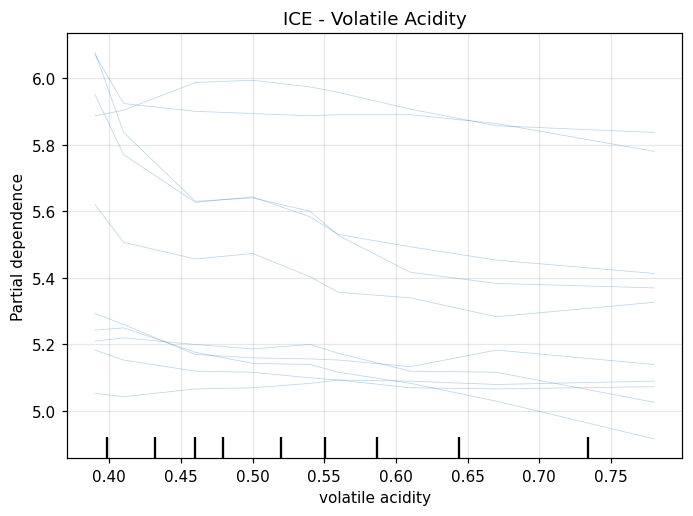

In [38]:
PartialDependenceDisplay.from_estimator(
    model,
    X_ice,
    features=["volatile acidity"],
    kind="individual",
    grid_resolution=50
)

plt.title("ICE - Volatile Acidity")
plt.tight_layout()
plt.show()

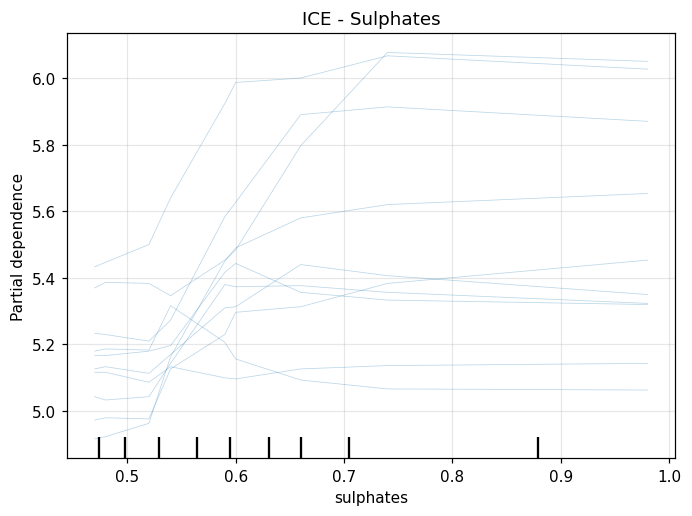

In [39]:
PartialDependenceDisplay.from_estimator(
    model,
    X_ice,
    features=["sulphates"],
    kind="individual",
    grid_resolution=50
)

plt.title("ICE - Sulphates")
plt.tight_layout()
plt.show()

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# Function to generate Raw ICE + PDP and Centered ICE
# ---------------------------------------------------------

def plot_ice_pdp_centered(model, X_data, feature, n_samples=50,
                          grid_points=50):

    # Select samples
    X_samples = X_data.iloc[:n_samples].copy()

    # Feature range
    feature_values = np.linspace(
        X_data[feature].min(),
        X_data[feature].max(),
        grid_points
    )

    # Store individual ICE predictions
    ice_predictions = []

    for value in feature_values:

        # Copy selected samples
        X_temp = X_samples.copy()

        # Change only the selected feature
        X_temp[feature] = value

        # Predict
        predictions = model.predict(X_temp)

        ice_predictions.append(predictions)

    # Convert to array
    ice_predictions = np.array(ice_predictions).T

    # Average PDP
    pdp_values = ice_predictions.mean(axis=0)

    # -----------------------------------------------------
    # Center ICE curves
    # -----------------------------------------------------

    # Subtract prediction at first feature value
    centered_ice = ice_predictions - ice_predictions[:, [0]]

    # Center PDP in the same way
    centered_pdp = pdp_values - pdp_values[0]


    # -----------------------------------------------------
    # Plot
    # -----------------------------------------------------

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(15, 5)
    )

    # =====================================================
    # LEFT: Raw ICE + PDP
    # =====================================================

    for i in range(ice_predictions.shape[0]):

        axes[0].plot(
            feature_values,
            ice_predictions[i],
            alpha=0.18,
            linewidth=0.8
        )

    # Average PDP
    axes[0].plot(
        feature_values,
        pdp_values,
        linestyle="--",
        linewidth=3,
        label="average"
    )

    axes[0].set_title(
        f"ICE + PDP — {feature} (raw)"
    )

    axes[0].set_xlabel(feature)
    axes[0].set_ylabel("Partial dependence")

    axes[0].legend()

    axes[0].grid(
        alpha=0.25
    )


    # =====================================================
    # RIGHT: Centered ICE
    # =====================================================

    for i in range(centered_ice.shape[0]):

        axes[1].plot(
            feature_values,
            centered_ice[i],
            alpha=0.18,
            linewidth=0.8
        )

    # Centered average
    axes[1].plot(
        feature_values,
        centered_pdp,
        linestyle="--",
        linewidth=3,
        label="average"
    )

    axes[1].set_title(
        f"Centred ICE — {feature}"
    )

    axes[1].set_xlabel(feature)
    axes[1].set_ylabel("Partial dependence")

    axes[1].legend()

    axes[1].grid(
        alpha=0.25
    )


    plt.tight_layout()
    plt.show()

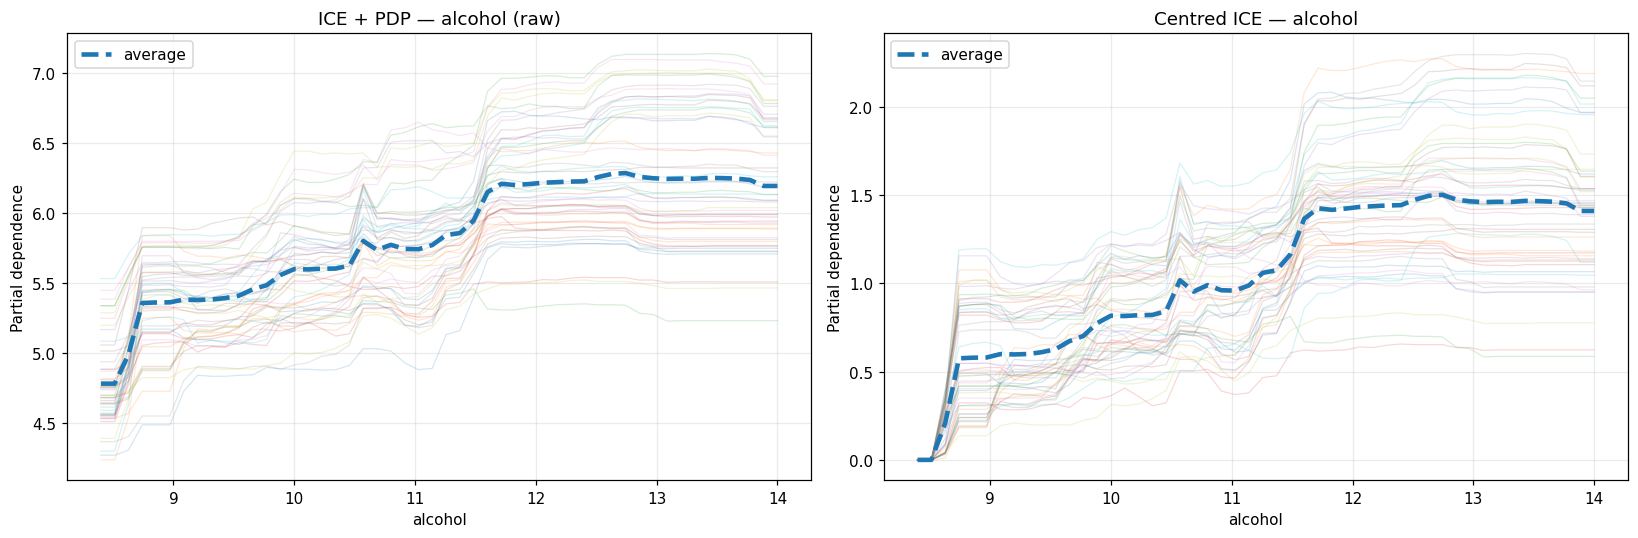

In [47]:
plot_ice_pdp_centered(
    model,
    X_test,
    "alcohol",
    n_samples=50,
    grid_points=50
)

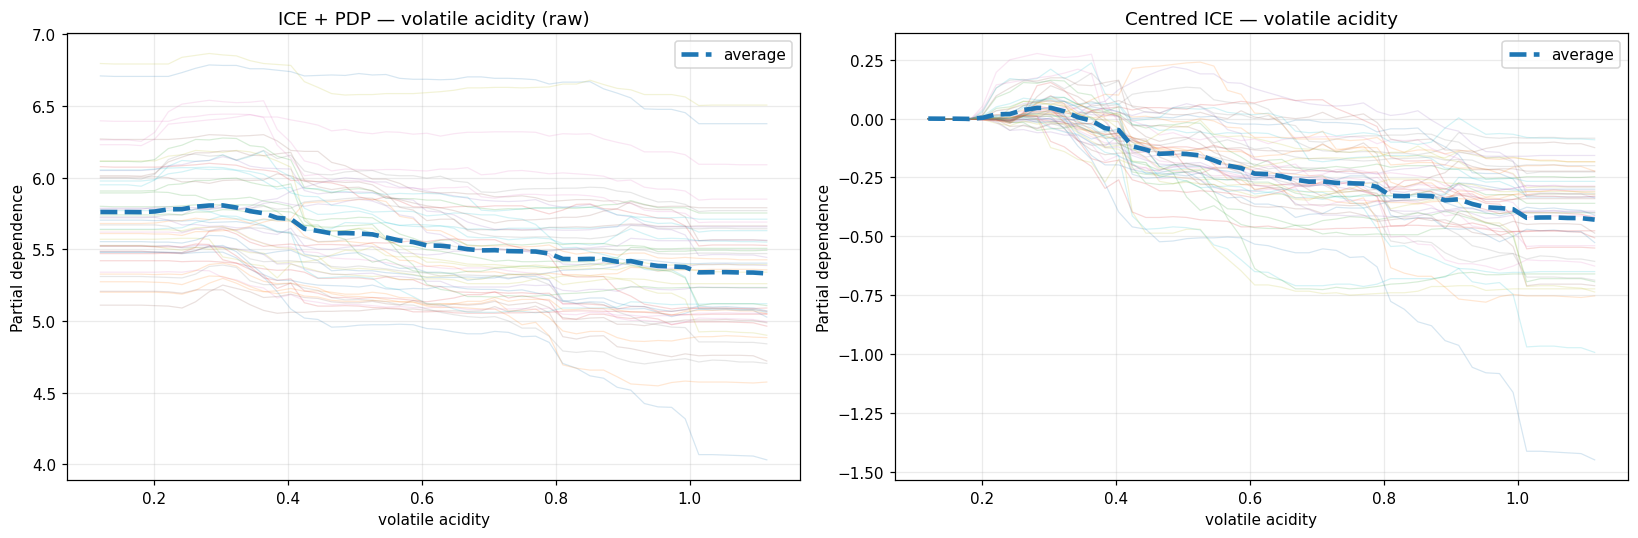

In [48]:
plot_ice_pdp_centered(
    model,
    X_test,
    "volatile acidity",
    n_samples=50,
    grid_points=50
)

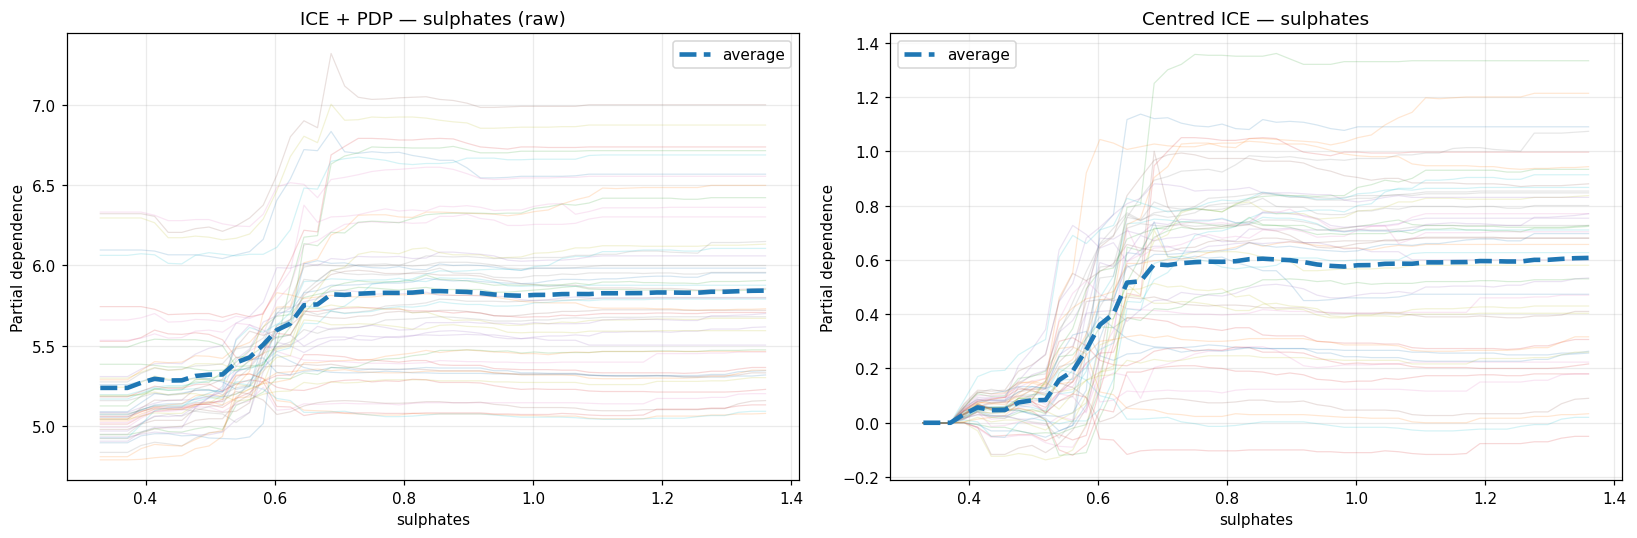

In [49]:
plot_ice_pdp_centered(
    model,
    X_test,
    "sulphates",
    n_samples=50,
    grid_points=50
)



---



TASK-05-Solution



---



In [40]:
from sklearn.inspection import permutation_importance

In [41]:
pfi_result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

print("Permutation Feature Importance calculated successfully.")

Permutation Feature Importance calculated successfully.


In [42]:
pfi_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": pfi_result.importances_mean,
    "Std": pfi_result.importances_std
})

pfi_df = pfi_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

pfi_df

,Feature,Importance,Std
0,alcohol,0.191157,0.014429
1,sulphates,0.129504,0.010693
2,volatile acidity,0.073666,0.008392
3,total sulfur dioxide,0.039610,0.007535
4,pH,0.015624,0.003900
5,free sulfur dioxide,0.015227,0.003627
6,density,0.014651,0.002525
7,fixed acidity,0.013208,0.002529
8,chlorides,0.009980,0.003702
9,citric acid,0.007747,0.002713


In [43]:
print("Permutation Feature Importance Ranking")
print("---------------------------------------")

for i, row in pfi_df.iterrows():
    print(
        f"{i+1:2d}. {row['Feature']:<22} "
        f"{row['Importance']:.4f}"
    )

Permutation Feature Importance Ranking
---------------------------------------
 1. alcohol                0.1912
 2. sulphates              0.1295
 3. volatile acidity       0.0737
 4. total sulfur dioxide   0.0396
 5. pH                     0.0156
 6. free sulfur dioxide    0.0152
 7. density                0.0147
 8. fixed acidity          0.0132
 9. chlorides              0.0100
10. citric acid            0.0077
11. residual sugar         0.0071


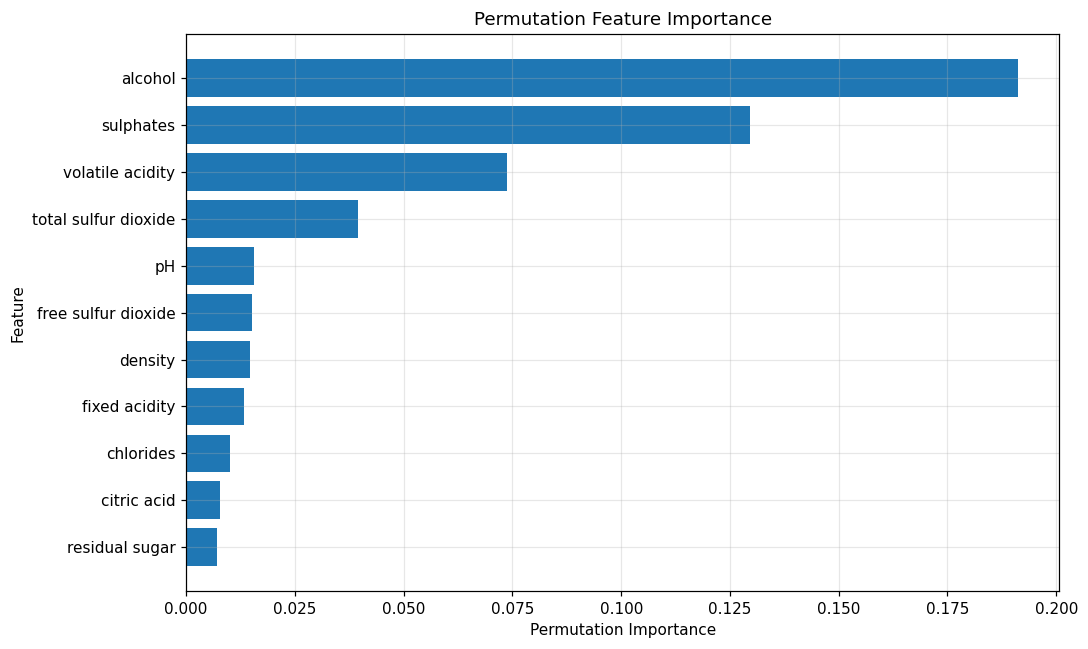

In [44]:
plt.figure(figsize=(10, 6))

plt.barh(
    pfi_df["Feature"],
    pfi_df["Importance"]
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

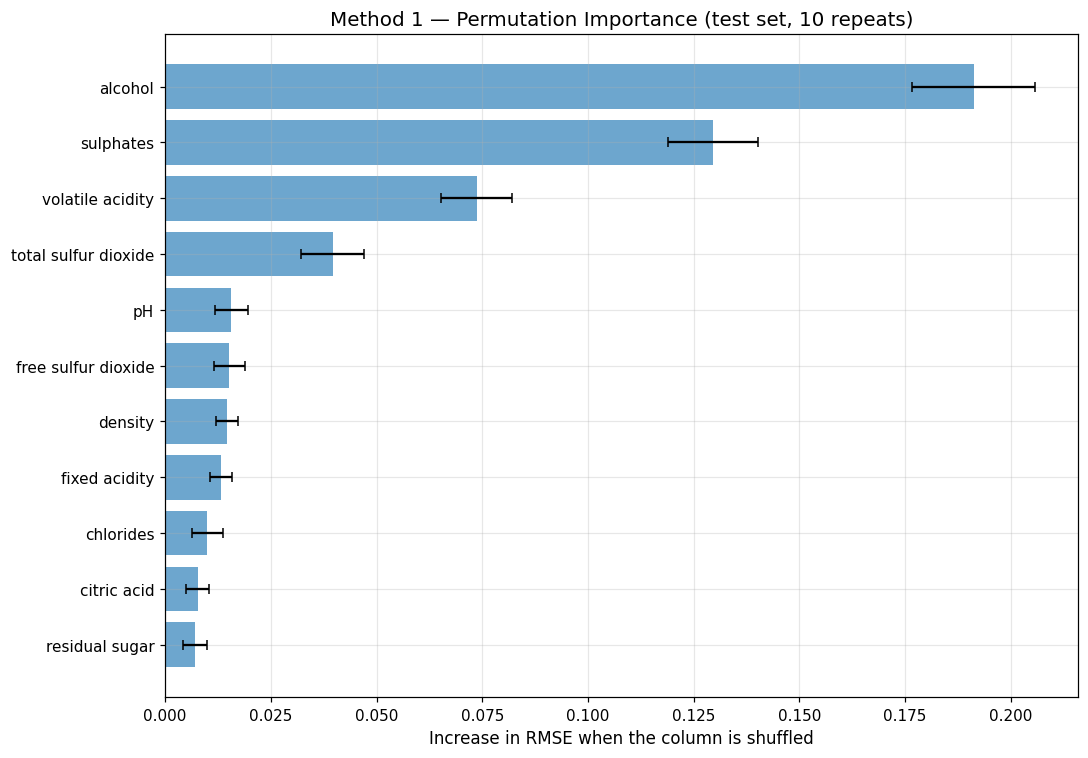

In [50]:
plt.figure(figsize=(10, 7))

plt.barh(
    pfi_df["Feature"][::-1],
    pfi_df["Importance"][::-1],
    xerr=pfi_df["Std"][::-1],
    capsize=3,
    alpha=0.65
)

plt.xlabel(
    "Increase in RMSE when the column is shuffled",
    fontsize=11
)

plt.title(
    "Method 1 — Permutation Importance (test set, 10 repeats)",
    fontsize=13
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [45]:
top_features = pfi_df.head(5)

print("Top 5 Most Important Features:")
print(top_features[["Feature", "Importance"]])

Top 5 Most Important Features:
                Feature  Importance
0               alcohol    0.191157
1             sulphates    0.129504
2      volatile acidity    0.073666
3  total sulfur dioxide    0.039610
4                    pH    0.015624




---



TASK-06-Solution



---



**1. Which features are most influential?**

Based on the Permutation Feature Importance results, alcohol is the most influential feature, followed by sulphates and volatile acidity. Alcohol has the highest permutation importance (0.1912), indicating that randomly shuffling it causes the largest degradation in model performance. Sulphates (0.1295) and volatile acidity (0.0737) are the next most influential features.

**2. What is the relationship between the important features and the prediction?**

The PDP results show different relationships:

Alcohol: Predicted wine quality generally increases as alcohol increases. The increase is particularly noticeable around the higher alcohol range.
Volatile acidity: Predicted quality generally decreases as volatile acidity increases.
Sulphates: Predicted quality generally increases as sulphates increase, particularly in the lower-to-middle range, after which the curve begins to level off.

Therefore, alcohol and sulphates have predominantly positive relationships with predicted quality, while volatile acidity has a predominantly negative relationship.

**3. Is the relationship linear or nonlinear?**

The relationships are nonlinear rather than strictly linear.

The alcohol PDP shows several changes in slope and a noticeable increase around the higher alcohol range. The sulphates PDP rises substantially at first and then begins to plateau. The volatile acidity PDP decreases overall but also contains sections with different rates of decline.

Therefore, the Random Forest model has learned nonlinear feature–prediction relationships.

**4. Do individual ICE curves follow the average PDP trend?**

Generally yes, but not perfectly.

The ICE curves broadly support the PDP trends:

For alcohol, many individual curves show increasing predictions as alcohol increases, although some individual curves behave differently at certain ranges.
For volatile acidity, many curves generally decrease as volatile acidity increases, consistent with the PDP.
For sulphates, several individual curves show increases, particularly in the lower-to-middle sulphate range, followed by relatively smaller changes at higher values.

Thus, the average PDP trend is visible in the individual ICE curves, but the ICE plots reveal additional sample-level variation that the PDP hides.

**5. Are there differences between individual samples?**

Yes.

The ICE plots show clear differences between individual wine samples. The curves do not all have identical shapes or magnitudes.

For example, the alcohol ICE plot contains samples with relatively strong increases as alcohol changes, while other samples show smaller changes or even local decreases. Similar variation is visible for volatile acidity and sulphates.

This indicates that the effect of a feature can depend on the characteristics of the individual wine, suggesting that feature interactions or sample-specific model behavior may be present.

**6. Does the PFI ranking agree with the PDP and ICE observations?**

Yes, the results are broadly consistent.

PFI identifies:

Alcohol → Sulphates → Volatile Acidity

as the three most influential features.

These are exactly the three features examined using PDP and ICE. The PDP plots show substantial changes in predicted quality for these features, while the ICE plots show that these effects are also visible across individual samples.

Therefore, the three XAI techniques provide broadly consistent evidence:

PFI identifies which features matter most.
PDP shows the average direction and shape of their effects.
ICE shows how those effects vary across individual wines.



---



**Final Observation:**

PDP, ICE, and PFI provide complementary information about the trained Random Forest model. PFI identifies the features that have the greatest impact on model performance, with alcohol, sulphates, and volatile acidity being the three most influential features. PDP reveals the average relationship between these features and predicted wine quality, showing that alcohol and sulphates generally have positive effects while volatile acidity has a negative effect. The relationships are nonlinear, as indicated by changes in the slopes and plateaus in the PDP curves. ICE provides a more detailed sample-level view and shows that individual wines can respond differently to changes in the same feature. Overall, the PFI, PDP, and ICE results are broadly consistent and together provide a more complete explanation of feature importance, average model behavior, and individual prediction behavior.



---

